=== MÔ HÌNH BAN ĐẦU (OVERFITTING) ===
Bậc đa thức quá cao (Degree = 9) dẫn tới việc mô hình khớp cả nhiễu dữ liệu.


-> Kết quả K-Fold (K=4): Bậc tối ưu tìm được là Degree = 2


 KẾT QUẢ DỰ ĐOÁN TẠI X = 2.0000
1. Giá trị y gốc lý tưởng sin(X)  : 0.9093
2. y dự đoán từ mô hình OVERFIT  : 1.0009 (Độ lệch: 0.0916)
3. y dự đoán từ mô hình TỐI ƯU   : 0.8688 (Độ lệch: 0.0405)


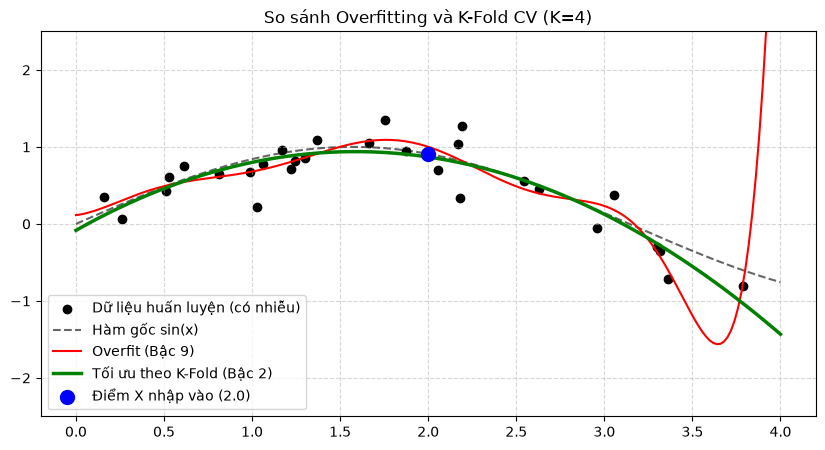

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(302)

# --- 1. CÁC HÀM NỀN TẢNG (TỪ FILE DỰ ÁN) ---

def make_polynomial_features(x, degree):
    """Tạo các đặc trưng đa thức: X = [1, x, x^2, ..., x^degree]"""
    x = np.array(x).reshape(-1, 1)
    return np.hstack([x**i for i in range(degree + 1)])

def fit_linear_regression(X, y):
    """Huấn luyện mô hình: w = (X^T * X)^(-1) * X^T * y"""
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def predict(X, w):
    """Dự đoán giá trị y"""
    return X @ w

def mean_squared_error(y_true, y_pred):
    """Tính sai số bình phương trung bình (MSE)"""
    return np.mean((y_true - y_pred) ** 2)

def k_fold_split(n_samples, k=5, shuffle=True):
    """Chia dữ liệu thành K tập validation và training"""
    indices = np.arange(n_samples)
    if shuffle:
        np.random.shuffle(indices)
    folds = np.array_split(indices, k)
    splits = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        splits.append((train_idx, val_idx))
    return splits

# --- 2. TỰ ĐỘNG SINH DỮ LIỆU CÓ NHIỄU ---
n_samples = 30
x_train = np.sort(np.random.rand(n_samples, 1) * 4, axis=0)
y_train = np.sin(x_train).ravel() + np.random.normal(0, 0.25, n_samples)

# --- 3. TẠO MÔ HÌNH BỊ OVERFITTING (BẬC 9) ---
DEGREE_OVERFIT = 9
X_train_poly = make_polynomial_features(x_train, DEGREE_OVERFIT)
w_overfit = fit_linear_regression(X_train_poly, y_train)

print("=== MÔ HÌNH BAN ĐẦU (OVERFITTING) ===")
print(f"Bậc đa thức quá cao (Degree = {DEGREE_OVERFIT}) dẫn tới việc mô hình khớp cả nhiễu dữ liệu.\n")

# --- 4. NHẬP HỆ SỐ K VÀ TÌM BẬC TỐI ƯU BẰNG K-FOLD CV ---
try:
    k_input = int(input(f"Nhập số tập K-Fold (Gợi ý: 3 đến 10, dữ liệu hiện tại n={n_samples}): "))
except ValueError:
    k_input = 5
    print(f"Giá trị nhập không hợp lệ! Tự động chọn K = {k_input}")

splits = k_fold_split(n_samples, k=k_input, shuffle=True)
candidate_degrees = list(range(1, 10))
cv_errors = []

for deg in candidate_degrees:
    fold_errors = []
    for train_idx, val_idx in splits:
        x_tr_fold, y_tr_fold = x_train[train_idx], y_train[train_idx]
        x_val_fold, y_val_fold = x_train[val_idx], y_train[val_idx]

        X_tr_fold = make_polynomial_features(x_tr_fold, deg)
        X_val_fold = make_polynomial_features(x_val_fold, deg)

        w_fold = fit_linear_regression(X_tr_fold, y_tr_fold)
        val_pred = predict(X_val_fold, w_fold)
        fold_errors.append(mean_squared_error(y_val_fold, val_pred))

    cv_errors.append(np.mean(fold_errors))

best_degree = candidate_degrees[np.argmin(cv_errors)]

# Huấn luyện lại mô hình tối ưu với bậc vừa chọn
X_train_best = make_polynomial_features(x_train, best_degree)
w_best = fit_linear_regression(X_train_best, y_train)

print(f"\n-> Kết quả K-Fold (K={k_input}): Bậc tối ưu tìm được là Degree = {best_degree}\n")

# --- 5. NHẬP X ĐỂ DỰ ĐOÁN VÀ SO SÁNH GIA TRỊ Y GỐC ---
try:
    x_val_input = float(input("Nhập giá trị X cần dự đoán (ví dụ từ 0.0 đến 4.0): "))
except ValueError:
    x_val_input = 2.0
    print(f"Giá trị nhập không hợp lệ! Tự động chọn X = {x_val_input}")

# Giá trị y thực tế theo hàm sinh gốc sin(x)
y_true_actual = np.sin(x_val_input)

# Dự đoán từ mô hình bị Overfit
X_input_overfit = make_polynomial_features([x_val_input], DEGREE_OVERFIT)
y_pred_overfit = predict(X_input_overfit, w_overfit)[0]

# Dự đoán từ mô hình Tối ưu
X_input_best = make_polynomial_features([x_val_input], best_degree)
y_pred_best = predict(X_input_best, w_best)[0]

# --- 6. HIỂN THỊ KẾT QUẢ SO SÁNH ---
print("\n" + "="*50)
print(f" KẾT QUẢ DỰ ĐOÁN TẠI X = {x_val_input:.4f}")
print("="*50)
print(f"1. Giá trị y gốc lý tưởng sin(X)  : {y_true_actual:.4f}")
print(f"2. y dự đoán từ mô hình OVERFIT  : {y_pred_overfit:.4f} (Độ lệch: {abs(y_true_actual - y_pred_overfit):.4f})")
print(f"3. y dự đoán từ mô hình TỐI ƯU   : {y_pred_best:.4f} (Độ lệch: {abs(y_true_actual - y_pred_best):.4f})")
print("="*50)

# --- 7. VẼ ĐỒ THỊ BỔ TRỢ QUAN SÁT ---
x_plot = np.linspace(0, 4, 200)[:, np.newaxis]
y_plot_true = np.sin(x_plot).ravel()
X_plot_overfit = make_polynomial_features(x_plot, DEGREE_OVERFIT)
X_plot_best = make_polynomial_features(x_plot, best_degree)

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, color='black', label='Dữ liệu huấn luyện (có nhiễu)')
plt.plot(x_plot, y_plot_true, 'k--', alpha=0.6, label='Hàm gốc sin(x)')
plt.plot(x_plot, predict(X_plot_overfit, w_overfit), color='red', label=f'Overfit (Bậc {DEGREE_OVERFIT})')
plt.plot(x_plot, predict(X_plot_best, w_best), color='green', linewidth=2.5, label=f'Tối ưu theo K-Fold (Bậc {best_degree})')
plt.scatter([x_val_input], [y_true_actual], color='blue', s=100, zorder=5, label=f'Điểm X nhập vào ({x_val_input})')

plt.ylim(-2.5, 2.5)
plt.title(f"So sánh Overfitting và K-Fold CV (K={k_input})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()